In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('Churn_Modelling.csv')

In [3]:
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [8]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [9]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [10]:
df.drop(columns=['CustomerId','Surname','RowNumber'],inplace=True)

In [11]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True,dtype=int)

In [13]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=['Exited'])
y=df['Exited']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [14]:
X_train.shape

(8000, 11)

In [15]:
X.shape

(10000, 11)

In [16]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [17]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]], shape=(8000, 11))

In [18]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [19]:
model=Sequential()
# model.add(Dense(3,activation='sigmoid',input_dim=11))
model.add(Dense(5,activation='relu',input_dim=11))
model.add(Dense(5,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

C:\Users\Asus\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 5)                   │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               6 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 96 (384.00 B)

 Trainable params: 96 (384.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [25]:
history=model.fit(X_train_scaled,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7575 - loss: 0.5769 - val_accuracy: 0.7981 - val_loss: 0.5196
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7970 - loss: 0.4995 - val_accuracy: 0.7975 - val_loss: 0.4843
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7972 - loss: 0.4735 - val_accuracy: 0.7975 - val_loss: 0.4666
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7975 - loss: 0.4597 - val_accuracy: 0.7975 - val_loss: 0.4555
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7978 - loss: 0.4508 - val_accuracy: 0.7981 - val_loss: 0.4480
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7981 - loss: 0.4443 - val_accuracy: 0.7981 - val_loss: 0.4424
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7987 - loss: 0.4396 - val_accuracy: 0.7969 - val_loss: 0.4378
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7987 - loss: 0.4353 - val_accuracy: 0.

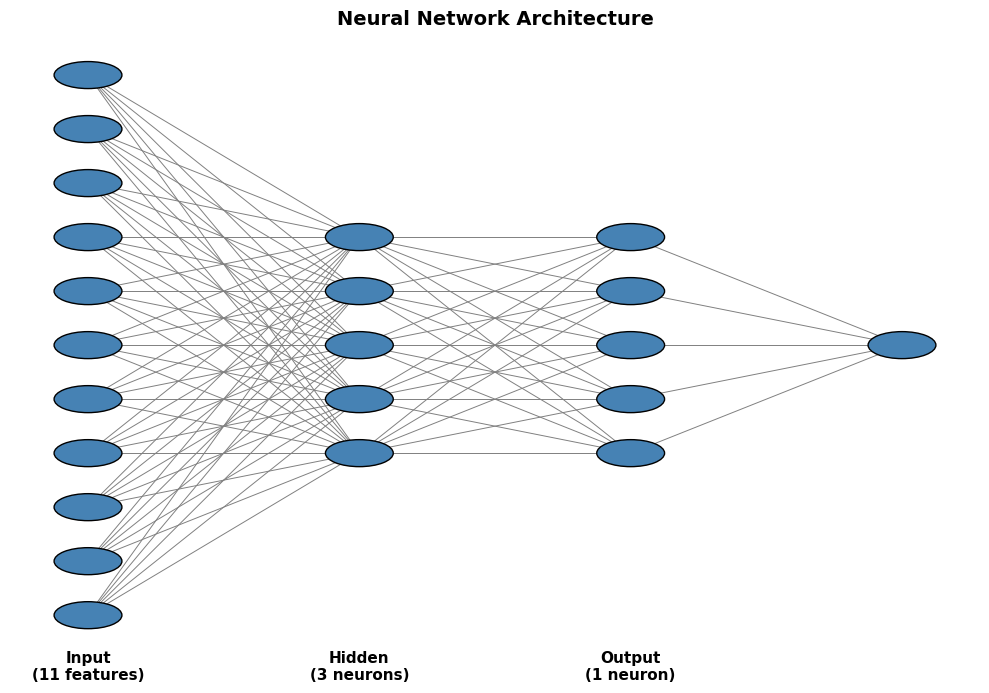

In [30]:
import matplotlib.pyplot as plt
import numpy as np

def draw_neural_network(layer_sizes, layer_labels=None):
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.axis('off')
    v_spacing = 1.0
    h_spacing = 2.0
    layer_positions = [i * h_spacing for i in range(len(layer_sizes))]
    node_coords = []

    for i, (x, size) in enumerate(zip(layer_positions, layer_sizes)):
        y_positions = np.linspace(0, (size - 1) * v_spacing, size)
        y_positions -= y_positions.mean()
        node_coords.append(list(zip([x]*size, y_positions)))
        for y in y_positions:
            circle = plt.Circle((x, y), 0.25, color='steelblue', ec='black', zorder=4)
            ax.add_patch(circle)

    for i in range(len(layer_sizes) - 1):
        for (x1, y1) in node_coords[i]:
            for (x2, y2) in node_coords[i+1]:
                ax.plot([x1, x2], [y1, y2], 'gray', lw=0.7, zorder=1)

    labels = layer_labels or [f'Layer {i+1}\n({s})' for i, s in enumerate(layer_sizes)]
    for x, label in zip(layer_positions, labels):
        ax.text(x, min(y for _, y in node_coords[0]) - 1.2,
                label, ha='center', fontsize=11, fontweight='bold')

    ax.autoscale()
    plt.title('Neural Network Architecture', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

draw_neural_network([11, 5, 5,1], ['Input\n(11 features)', 'Hidden\n(3 neurons)', 'Output\n(1 neuron)'])

In [163]:
model.layers[1].get_weights()

[array([[-0.01038914,  0.4120927 ,  0.4795438 , -0.15466279, -0.46961737],
        [ 0.7898154 ,  0.5663404 ,  0.17674287,  0.3691256 , -0.3002643 ],
        [ 0.17898147,  0.5276472 ,  0.10029332,  0.0648194 , -0.39671564],
        [ 0.78479916, -0.7801355 ,  0.7039402 ,  0.01781446, -0.32979396],
        [ 0.28631514,  0.60150045, -0.21044505,  0.23105517, -0.5783794 ]],
       dtype=float32),
 array([-0.00735735, -0.02977465,  0.06927996, -0.00399066,  0.        ],
       dtype=float32)]

In [164]:
y_log=model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [165]:
y_pred=np.where(y_log>0.5,1,0)

In [166]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8045

In [167]:
import matplotlib.pyplot as plt

In [168]:
history.history

{'accuracy': [0.7962499856948853,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.797656238079071,
  0.800000011920929,
  0.8089062571525574],
 'loss': [0.5141788721084595,
  0.4718325734138489,
  0.45458468794822693,
  0.4446152150630951,
  0.4382208585739136,
  0.43379098176956177,
  0.4303644299507141,
  0.42728108167648315,
  0.42418864369392395,
  0.4208841621875763],
 'val_accuracy': [0.7975000143051147,
  0.7975000143051147,
  0.7975000143051147,
  0.7975000143051147,
  0.7975000143051147,
  0.7975000143051147,
  0.796875,
  0.7987499833106995,
  0.8012499809265137,
  0.8018749952316284],
 'val_loss': [0.47340166568756104,
  0.4520333409309387,
  0.44105595350265503,
  0.4356951117515564,
  0.43245795369148254,
  0.4301804006099701,
  0.4287804663181305,
  0.42698776721954346,
  0.42447566986083984,
  0.4222206771373749]}

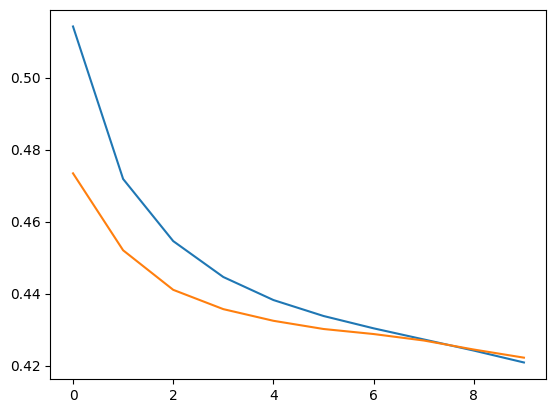

In [169]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])


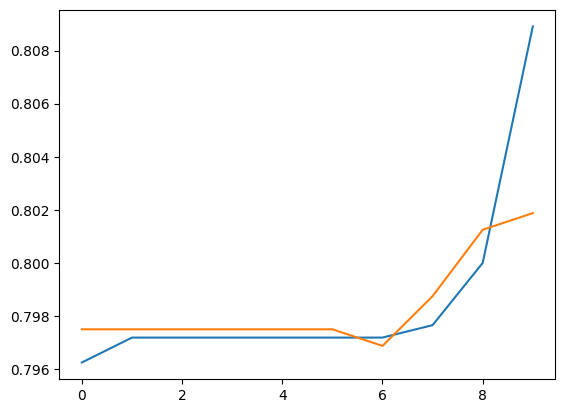

In [170]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])